In [ ]:
import numpy as np 
import pandas as pd 
import os

# Data Collection & Understanding

In [2]:
data_supply = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', encoding = "latin1")
data_supply.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per customer

In [3]:
data_supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

# EDA

## Overview

In [4]:
data_supply.shape

(180519, 53)

In [5]:
data_supply.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [6]:
data_supply.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [7]:
data_supply = data_supply.drop(
    columns=['Product Description', 'Order Zipcode']
)

In [8]:
missing = data_supply.isnull().sum()
missing_percent = (missing / len(data_supply)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

missing_table.sort_values('Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662
Days for shipping (real),0,0.000000
Days for shipment (scheduled),0,0.000000
Benefit per order,0,0.000000
Delivery Status,0,0.000000
Sales per customer,0,0.000000
Category Id,0,0.000000
Category Name,0,0.000000
Customer City,0,0.000000


In [9]:
data_supply.dropna()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


## Distribusi & Correlation Data

<Axes: >

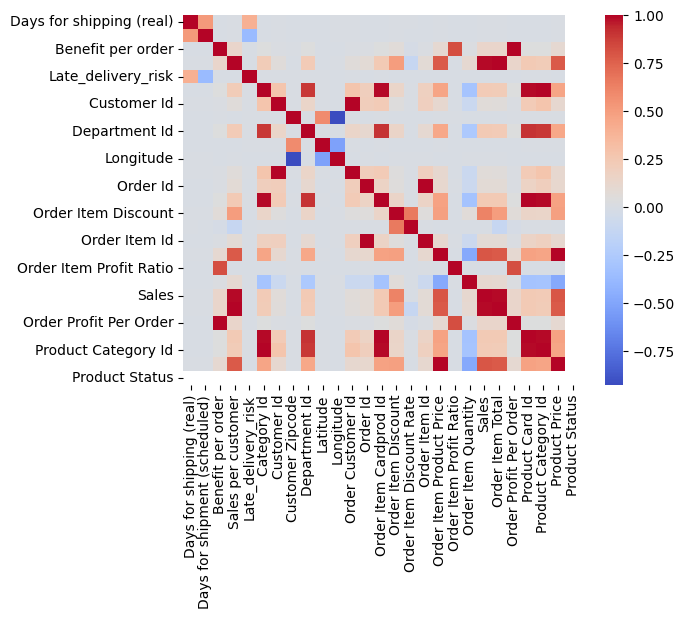

In [10]:
import seaborn as sns

corr = data_supply.select_dtypes(include='number').corr()

sns.heatmap(corr, cmap='coolwarm')

<Axes: xlabel='Sales', ylabel='Count'>

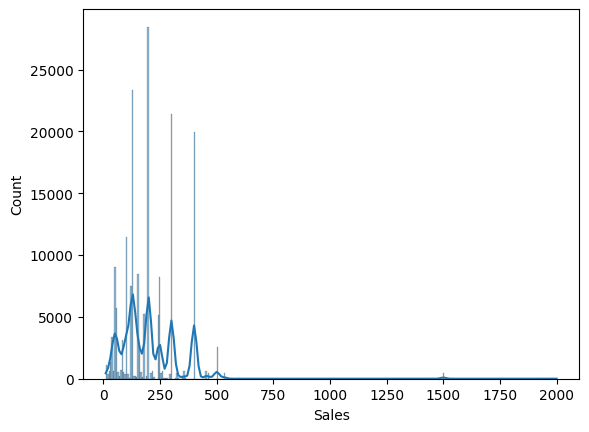

In [11]:
sns.histplot(data_supply['Sales'], kde=True)

In [12]:
## Boxplot dataset supply

## Shipping Performance

In [13]:
data_supply['Shipping_Delay'] = (
    data_supply['Days for shipping (real)']
    - data_supply['Days for shipment (scheduled)']
)

<Axes: xlabel='Shipping_Delay', ylabel='Count'>

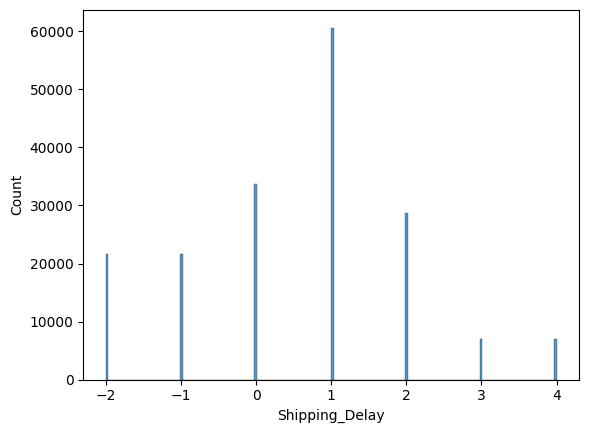

In [14]:
sns.histplot(data_supply['Shipping_Delay'])

## Late Delivery Risk Analysis

<Axes: xlabel='Late_delivery_risk', ylabel='count'>

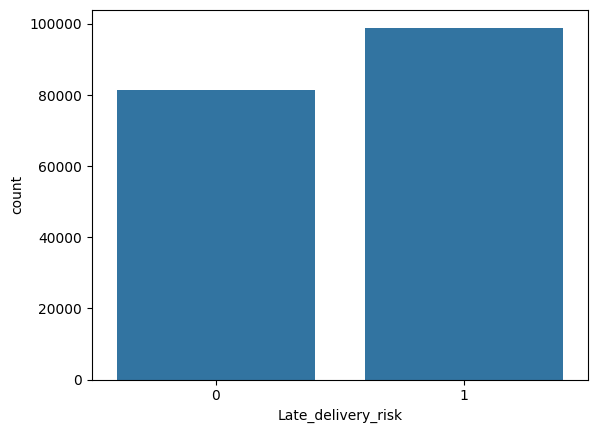

In [15]:
sns.countplot(x='Late_delivery_risk', data=data_supply)

<Axes: xlabel='Late_delivery_risk', ylabel='Days for shipping (real)'>

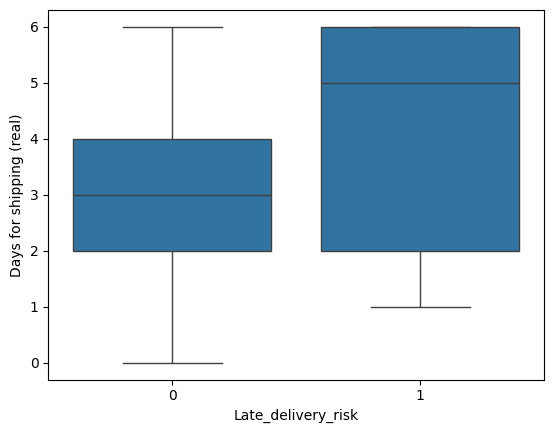

In [16]:
sns.boxplot(x='Late_delivery_risk',
            y='Days for shipping (real)',
            data=data_supply)

<Axes: xlabel='Late_delivery_risk', ylabel='Shipping_Delay'>

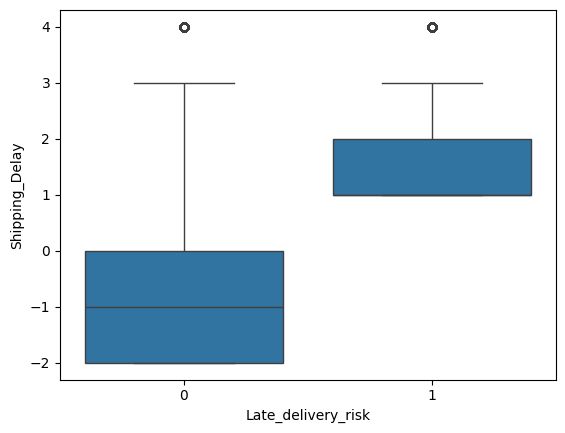

In [17]:
sns.boxplot(
    x='Late_delivery_risk',
    y='Shipping_Delay',
    data=data_supply
)

<Axes: xlabel='Shipping Mode', ylabel='Shipping_Delay'>

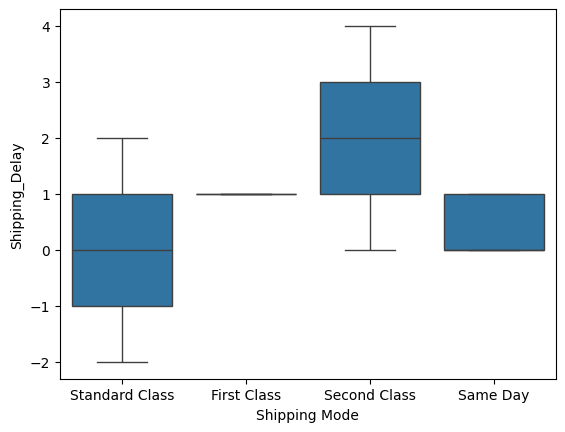

In [18]:
sns.boxplot(
    x='Shipping Mode',
    y='Shipping_Delay',
    data=data_supply
)

<Axes: xlabel='Market', ylabel='count'>

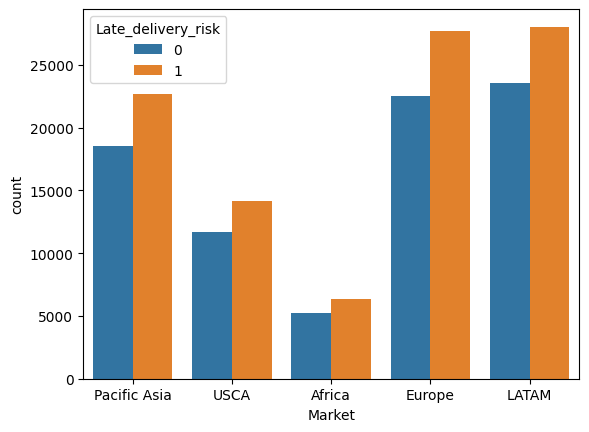

In [19]:
sns.countplot(
    data=data_supply,
    x='Market',
    hue='Late_delivery_risk'
)

## Pricing Analysis

<Axes: ylabel='Order Item Product Price'>

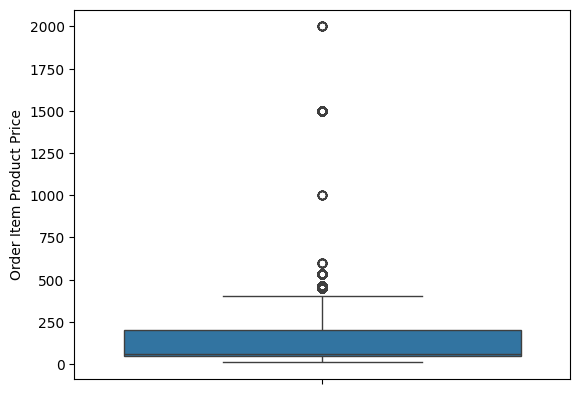

In [20]:
sns.boxplot(y=data_supply['Order Item Product Price'])

In [21]:
data_supply['Price_Ratio'] = (
    data_supply['Order Item Product Price']
    / data_supply['Product Price'])

## Profit Analysis

<Axes: xlabel='Order Profit Per Order', ylabel='Count'>

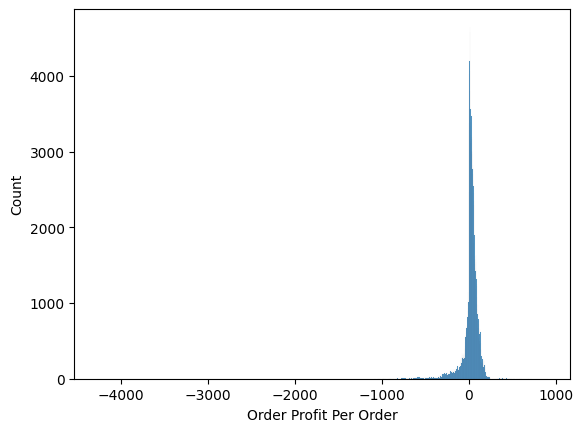

In [22]:
sns.histplot(data_supply['Order Profit Per Order'])

## Fraudiness

<Axes: ylabel='Order Item Product Price'>

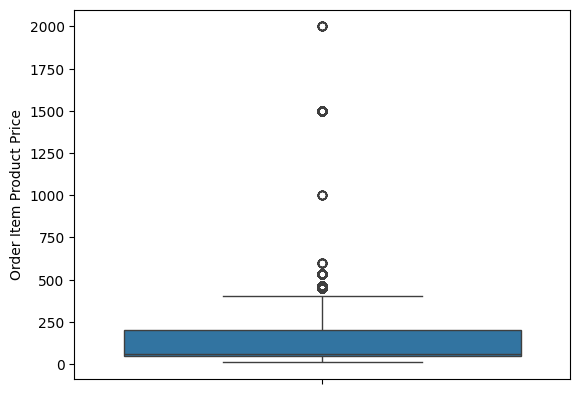

In [23]:
sns.boxplot(y=data_supply['Order Item Product Price'])

<Axes: xlabel='Price_Ratio', ylabel='Count'>

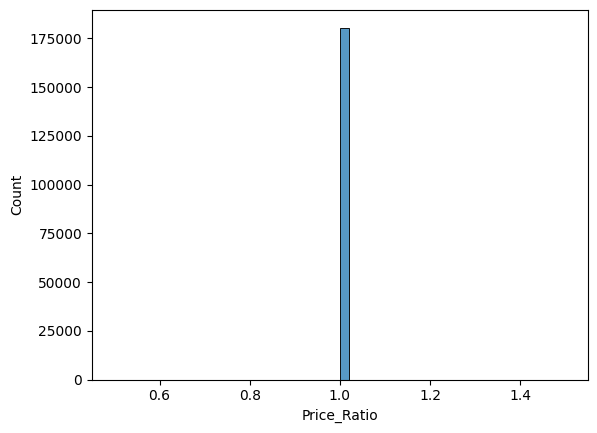

In [24]:
sns.histplot(data_supply['Price_Ratio'], bins=50)

<Axes: ylabel='Order Profit Per Order'>

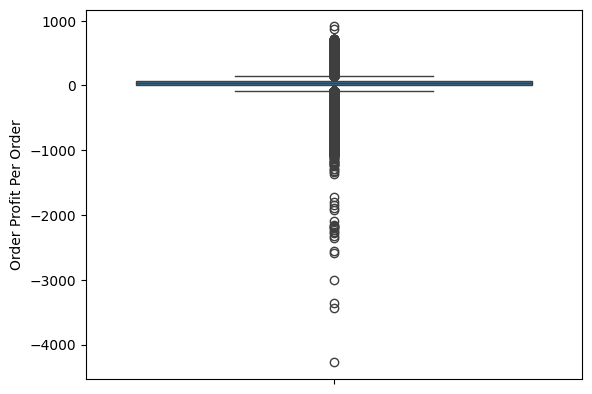

In [25]:
sns.boxplot(y=data_supply['Order Profit Per Order'])

<Axes: xlabel='Order Item Discount Rate', ylabel='Count'>

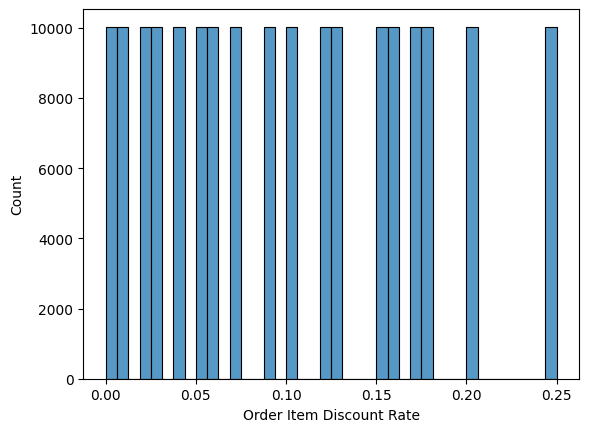

In [26]:
# Discount Analysis

sns.histplot(
    data_supply['Order Item Discount Rate'],
    bins=40
)

## Inventory Manipulation

<Axes: ylabel='Order Item Quantity'>

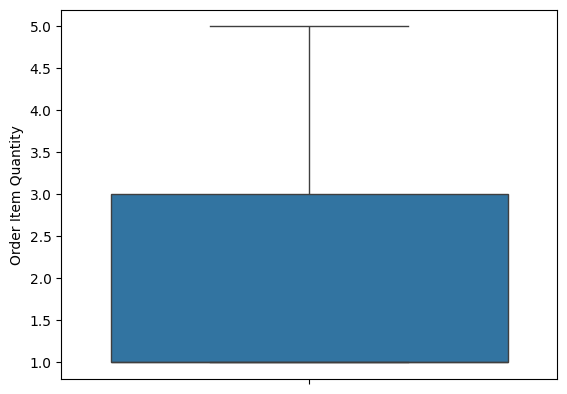

In [27]:
# Quantity Distribution

sns.boxplot(y=data_supply['Order Item Quantity'])

<Axes: xlabel='Order Item Quantity', ylabel='Sales'>

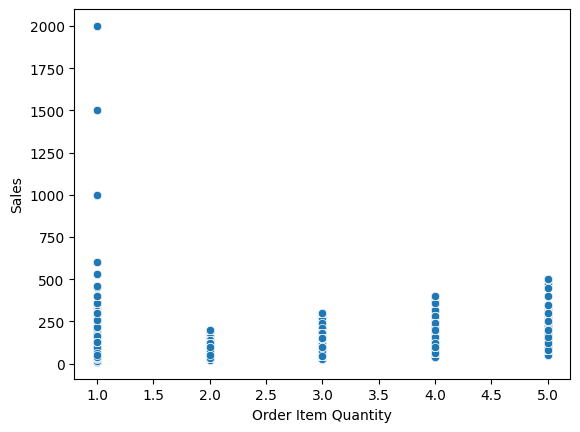

In [28]:
# Sales VS Quantity
sns.scatterplot(
    x='Order Item Quantity',
    y='Sales',
    data=data_supply
)

## Outlier Detection

<Axes: xlabel='Order Item Product Price'>

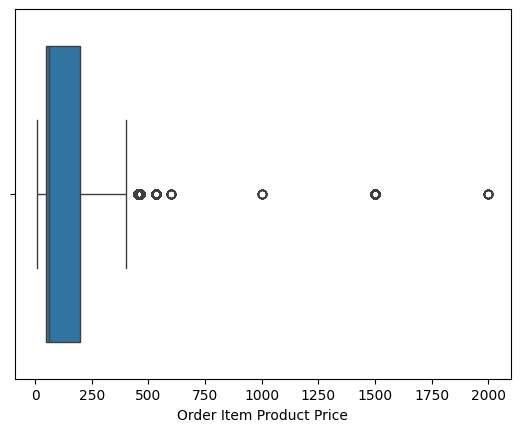

In [29]:
sns.boxplot(x=data_supply['Order Item Product Price'])

In [30]:
Q1 = data_supply['Order Item Product Price'].quantile(0.25)
Q3 = data_supply['Order Item Product Price'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = data_supply[
    (data_supply['Order Item Product Price'] < lower_bound) |
    (data_supply['Order Item Product Price'] > upper_bound)
]

outliers.head()

Q1: 50.0
Q3: 199.9900055
IQR: 149.9900055
Lower Bound: -174.98500825
Upper Bound: 424.97501375


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Shipping_Delay,Price_Ratio
146,DEBIT,4,2,120.830002,447.519989,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/18/2017 11:42,Second Class,2,1.0
148,DEBIT,6,2,212.639999,443.000000,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/22/2017 1:12,Second Class,4,1.0
150,DEBIT,6,2,135.830002,433.959992,Late delivery,1,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/19/2017 3:08,Second Class,4,1.0
152,DEBIT,5,2,595.349976,1417.500000,Late delivery,1,64,Computers,Caguas,...,1351,64,http://images.acmesports.sports/Dell+Laptop,Dell Laptop,1500.000000,0,11/3/2017 12:55,Second Class,3,1.0
153,DEBIT,2,2,21.360001,427.179993,Shipping on time,0,62,Cameras,Caguas,...,1349,62,http://images.acmesports.sports/Web+Camera,Web Camera,452.040008,0,10/15/2017 8:44,Second Class,0,1.0


# Data Splitting (biar gak Leakage)

In [31]:
# For Fraud Detection
.......

# For Demand Forecasting
.......

# For Late Shipment Risk
......

SyntaxError: invalid syntax (3167588072.py, line 2)

# Feature Engineering

## Fraud Detection

In [ ]:
# Pricing Fraud
......

# Delivery Fraud
.......

# Inventory Manipulation
.........


## Delivery Fraud

In [ ]:
# By Delay

## Late Shipment

In [ ]:
# Rsik
......

# Modelling for Deployment

In [ ]:
# import library


## Fraud Detection

### a. Pricing Fraud (by ratio)

### b. Delivery Fraud (by delay)

### c. Inventory Manipulation

## Demand Forecasting

In [ ]:
# Menggunakan Model Trend Analysis

## Late Shipment Risk

In [ ]:
# Menggunakan model probabilisitik/logistik

# Evaluasi/Backtesting

## 